In [2]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("train.csv")

df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [5]:
df.shape

(100000, 28)

In [6]:
df.size

2800000

In [7]:
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [9]:
df.isnull().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,9985
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,15002
Num_Bank_Accounts,0


In [10]:
df.describe(include='all')

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000,100000,100000,90015,100000,100000,100000,100000,84998.000000,100000.000000,...,100000,100000,100000.000000,90970,100000,100000.000000,95521,100000,98800,100000
unique,100000,12500,8,10139,1788,12501,16,18940,NaN,NaN,...,4,13178,NaN,404,3,NaN,91049,7,98792,3
top,0x25fd5,CUS_0x942c,January,Stevex,38,#F%$D@*&8,_______,36585.12,NaN,NaN,...,Standard,1360.45,NaN,15 Years and 11 Months,Yes,NaN,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,1,8,12500,44,2833,5572,7062,16,NaN,NaN,...,36479,24,NaN,446,52326,NaN,4305,25513,9,53174
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4194.170850,17.091280,...,NaN,NaN,32.285173,NaN,NaN,1403.118217,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3183.686167,117.404834,...,NaN,NaN,5.116875,NaN,NaN,8306.041270,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,303.645417,-1.000000,...,NaN,NaN,20.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1625.568229,3.000000,...,NaN,NaN,28.052567,NaN,NaN,30.306660,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3093.745000,6.000000,...,NaN,NaN,32.305784,NaN,NaN,69.249473,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5957.448333,7.000000,...,NaN,NaN,36.496663,NaN,NaN,161.224249,NaN,NaN,NaN,NaN


In [11]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

Name                        9985
Monthly_Inhand_Salary      15002
Type_of_Loan               11408
Num_of_Delayed_Payment      7002
Num_Credit_Inquiries        1965
Credit_History_Age          9030
Amount_invested_monthly     4479
Monthly_Balance             1200
dtype: int64


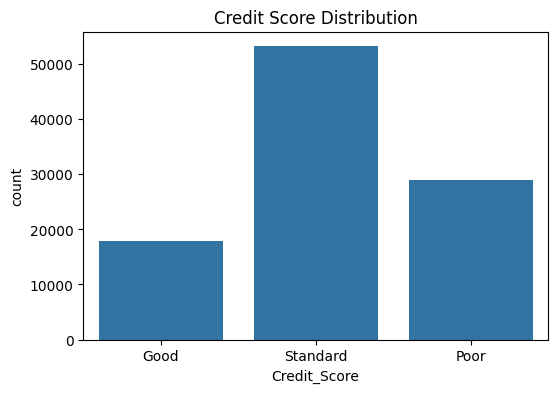

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x='Credit_Score', data=df)

plt.title("Credit Score Distribution")

plt.show()

In [13]:
df.drop(
    columns=[
        'ID',
        'Customer_ID',
        'Name',
        'SSN'
    ],
    inplace=True
)

In [1]:
def clean_numeric(col):

    return pd.to_numeric(
        col.astype(str).str.replace('_', ''),
        errors='coerce'
    )

In [15]:
numeric_cols = [
    'Age',
    'Annual_Income',
    'Monthly_Inhand_Salary',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Interest_Rate',
    'Num_of_Loan',
    'Delay_from_due_date',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Num_Credit_Inquiries',
    'Outstanding_Debt',
    'Credit_Utilization_Ratio',
    'Total_EMI_per_month',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

for col in numeric_cols:
    df[col] = clean_numeric(df[col])

In [16]:
def convert_history(text):

    try:
        years = int(str(text).split(' Years')[0])

        months = int(
            str(text).split('and ')[1]
            .split(' Months')[0]
        )

        return years*12 + months

    except:
        return np.nan

In [17]:
df['Credit_History_Age'] = \
df['Credit_History_Age'].apply(convert_history)

In [18]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [19]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [20]:
df['Debt_to_Income'] = (
    df['Outstanding_Debt']
    /
    (df['Annual_Income'] + 1)
)

In [21]:
df['EMI_to_Income'] = (
    df['Total_EMI_per_month']
    /
    (df['Monthly_Inhand_Salary'] + 1)
)

In [22]:
df['Credit_per_Loan'] = (
    df['Num_Credit_Card']
    /
    (df['Num_of_Loan'] + 1)
)

In [23]:
target = df['Credit_Score']

features = df.drop(
    'Credit_Score',
    axis=1
)

In [24]:
for col in features.select_dtypes(
    include='object'
).columns:

    le = LabelEncoder()

    features[col] = le.fit_transform(
        features[col]
    )

In [25]:
target_encoder = LabelEncoder()

target = target_encoder.fit_transform(
    target
)

In [26]:
X_train, X_test, y_train, y_test = \
train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

In [27]:
models = {

    "Logistic Regression":
    LogisticRegression(max_iter=1000),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        random_state=42
    )
}

In [28]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(
        y_test,
        pred
    )

    results.append(
        [name, acc]
    )

pd.DataFrame(
    results,
    columns=['Model','Accuracy']
)

,Model,Accuracy
0,Logistic Regression,0.29005
1,Decision Tree,0.68610
2,Random Forest,0.78105


In [29]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [30]:
y_pred = rf.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test,y_pred)
)

Accuracy: 0.77945


In [31]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=
        target_encoder.classes_
    )
)

              precision    recall  f1-score   support

        Good       0.70      0.72      0.71      3566
        Poor       0.78      0.78      0.78      5799
    Standard       0.81      0.80      0.80     10635

    accuracy                           0.78     20000
   macro avg       0.76      0.77      0.76     20000
weighted avg       0.78      0.78      0.78     20000



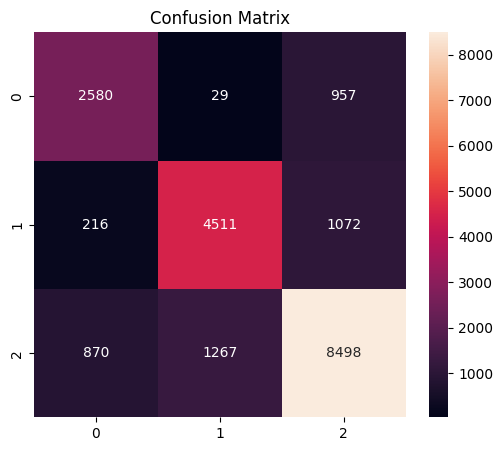

In [32]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Confusion Matrix"
)

plt.show()

In [33]:
probs = rf.predict_proba(X_test)

auc = roc_auc_score(
    y_test,
    probs,
    multi_class='ovr'
)

print(
    "ROC AUC:",
    round(auc,4)
)

ROC AUC: 0.9063


In [34]:
importance = pd.DataFrame({

    'Feature':
    features.columns,

    'Importance':
    rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

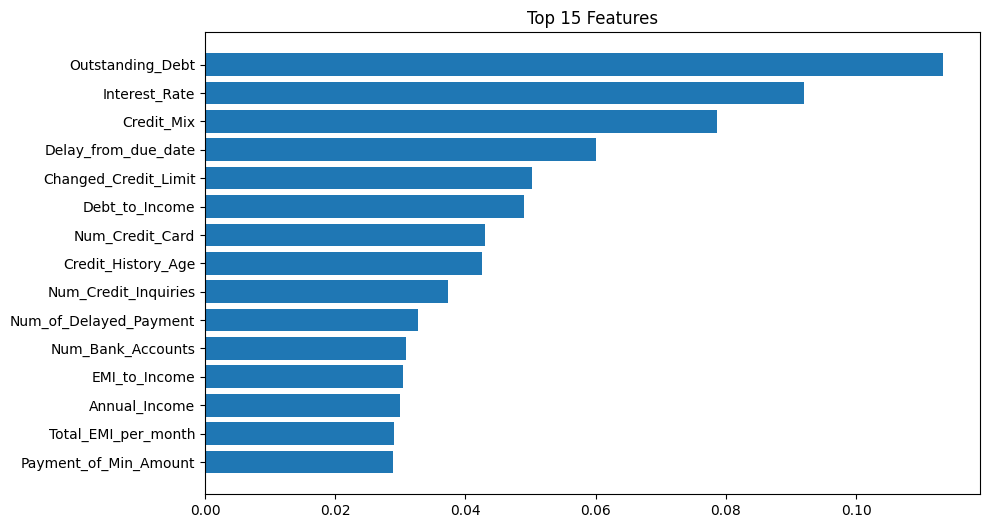

In [35]:
top = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top['Feature'],
    top['Importance']
)

plt.gca().invert_yaxis()

plt.title(
    "Top 15 Features"
)

plt.show()

In [36]:
import joblib

joblib.dump(
    rf,
    "credit_score_model.pkl"
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully
